### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\n\nStat'

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [21]:
### Tavily Search Tool
from langchain_tavily import TavilySearch

tavily = TavilySearch()

In [22]:
tavily.invoke("Provide me the recipie for chillie maggie")

{'query': 'Provide me the recipie for chillie maggie',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.peekncook.com/Show-A-Recipe/82334/chilli-garlic-maggi-noodles',
   'title': 'Hot Spicy Chilli Garlic Maggi Noodles - PeekNCook',
   'content': "# Hot Spicy Chilli Garlic Maggi Noodles. Hot Spicy Chilli Garlic Maggi Noodles. ## Chilli Garlic Maggi Noodles. This Chilli Garlic Maggi video demonstrates making Street Style Hot Garlic Maggi Masala, an easy bachelor's recipe for a quick evening snack. Simply toss cooked maggi in hot garlic oil. If you love chilli garlic noodles, try this chilli garlic Maggi too. This chili garlic noodle is an instant Maggi noodle recipe made with Maggi and Maggi tastemakers. ## Ingredients for Chilli Garlic Maggi Noodles. ## Preperation steps for Chilli Garlic Maggi Noodles. In a large mixing bowl, add crushed garlic, chilli flakes, chilli powder, maggi masala, chopped green chilli, chopped spring onion, soya s

In [23]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [26]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

In [27]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent AI News". They likely want a summary of recent AI news. Need up-to-date information. We have a search tool tavily_search for current events. Let\'s search for recent AI news.', 'tool_calls': [{'id': 'fc_ae547083-619b-473f-bfcf-86f0a7e725d7', 'function': {'arguments': '{"query":"latest AI news March 2026","search_depth":"advanced","time_range":"week"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 450, 'total_tokens': 549, 'completion_time': 0.217489202, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.017915916, 'prompt_tokens_details': None, 'queue_time': 0.045620824, 'total_time': 0.235405118}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--0

In [28]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'AI news March 2026',
   'search_depth': 'advanced',
   'time_range': 'month',
   'topic': 'news'},
  'id': 'fc_179b3fc5-a3a9-4bc0-9d41-5b069139e486',
  'type': 'tool_call'}]

In [29]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

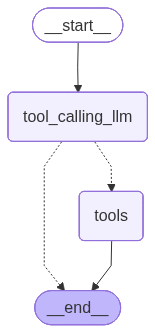

In [32]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [33]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_0512718d-a2d3-4949-8b11-04917bd7a9d0)
 Call ID: fc_0512718d-a2d3-4949-8b11-04917bd7a9d0
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [34]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 11th 2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 11th 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_beee3f23-4351-4b6d-827b-ca53c937041b)
 Call ID: fc_beee3f23-4351-4b6d-827b-ca53c937041b
  Args:
    query: AI news March 11 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news March 11 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.itnews.com.au/news/meta-acquires-ai-agent-social-network-moltbook-624175", "title": "Meta acquires AI agent social network Moltbook - iTnews", "score": 0.8593928, "published_date": "Tue, 10 Mar 2026 19:38:00 GMT", "content": "Latest News\n\n## Woolworths' AI customer problem-solving a question of semantics ## Meta acquires AI

In [37]:
messages=graph.invoke({"messages":HumanMessage(content="NOTE: DO NOT CALL WIKI TOOL,use search tool to find information about What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

NOTE: DO NOT CALL WIKI TOOL,use search tool to find information about What is machine learning
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1f06a17c-2412-4c5f-bab8-3a6ebd4b75aa)
 Call ID: fc_1f06a17c-2412-4c5f-bab8-3a6ebd4b75aa
  Args:
    query: What is machine learning definition
    search_depth: fast
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "What is machine learning definition", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.techemergence.com/what-is-machine-learning", "title": "What is Machine Learning? - An Informed Definition", "content": "\\ “Machine Learning is the science of getting computers to learn and act like humans do, and improve their learning over time in autonomous fashion, by feeding t